In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.fft import fft, fftfreq
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.signal import find_peaks
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
from statsmodels.tsa.stattools import grangercausalitytests
from scipy.stats import spearmanr, kendalltau
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import statsmodels.api as sm
from scipy.signal import csd
from scipy.stats import boxcox, yeojohnson
from sklearn.neighbors import KernelDensity
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

In [2]:
import os

# Construct path to data
base_dir = os.path.dirname(os.getcwd())
data_path = os.path.join(base_dir, 'data', 'raw', 'energy_data.csv')

# Check if running from notebook dir or project root
if not os.path.exists(data_path):
    # Fallback for direct path if needed
    data_path = r'c:\Users\SRIDHAR RAO\OneDrive\Desktop\1711\energy_consumption_project\data\raw\energy_data.csv'

print(f"Loading data from: {data_path}")
df = pd.read_csv(data_path)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
df.sort_index(inplace=True)

print("Data loaded successfully. Shape:", df.shape)
df.head()

Loading data from: c:\Users\SRIDHAR RAO\OneDrive\Desktop\1711\energy_consumption_project\data\raw\energy_data.csv
Data loaded successfully. Shape: (4321, 5)


,fridge,ac,lights,microwave,total_power
timestamp,,,,,
2023-01-01 00:00:00,119,0,59,0,178
2023-01-01 01:00:00,119,0,20,0,139
2023-01-01 02:00:00,0,0,78,0,78
2023-01-01 03:00:00,68,0,87,0,155
2023-01-01 04:00:00,162,0,61,0,223


Skewness of total_power: 0.5076
Kurtosis of total_power: -1.0878


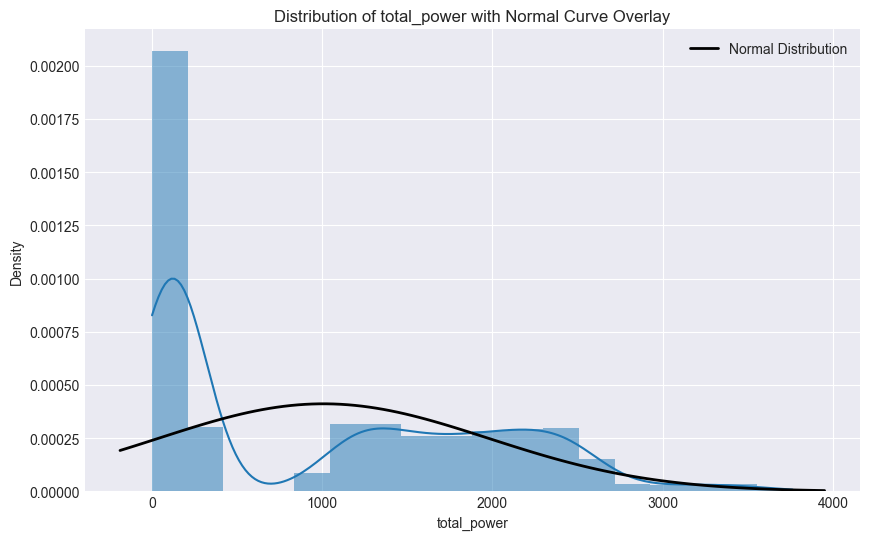

In [3]:
target_col = 'total_power'

# Calculate Skewness and Kurtosis
skewness = df[target_col].skew()
kurtosis = df[target_col].kurtosis()

print(f"Skewness of {target_col}: {skewness:.4f}")
print(f"Kurtosis of {target_col}: {kurtosis:.4f}")

# Visualize Distribution with KDE
plt.figure(figsize=(10, 6))
sns.histplot(df[target_col], kde=True, stat="density", linewidth=0)
# Overlay Normal Distribution for comparison
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, df[target_col].mean(), df[target_col].std())
plt.plot(x, p, 'k', linewidth=2, label='Normal Distribution')
plt.title(f'Distribution of {target_col} with Normal Curve Overlay')
plt.legend()
plt.show()

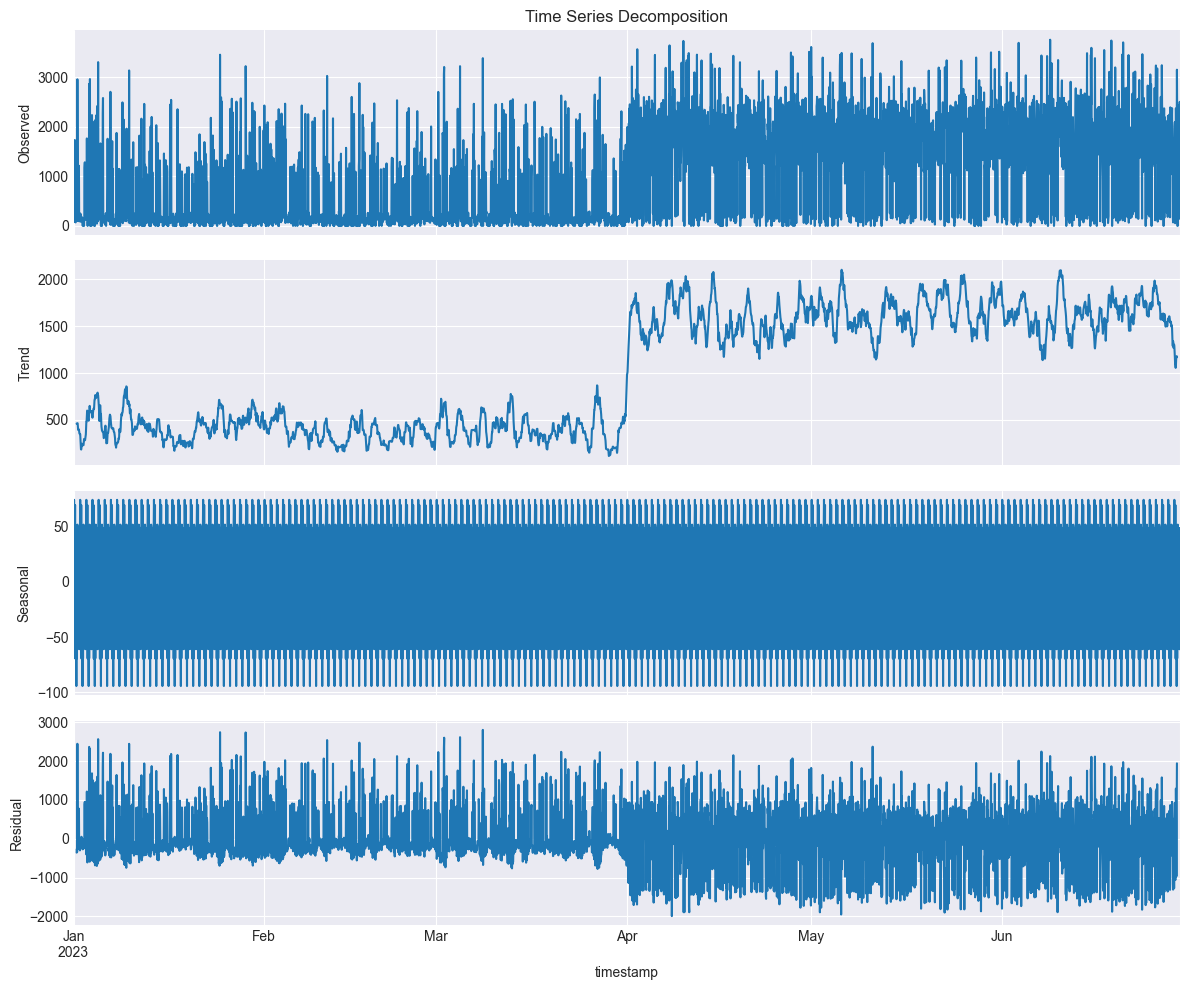

In [4]:
# Decompose the time series (assuming varying period, lets verify seasonality visually first)
# We'll use a period of 24 hours assuming daily seasonality
decomposition = seasonal_decompose(df[target_col], model='additive', period=24)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

decomposition.observed.plot(ax=ax1)
ax1.set_ylabel('Observed')
ax1.set_title('Time Series Decomposition')

decomposition.trend.plot(ax=ax2)
ax2.set_ylabel('Trend')

decomposition.seasonal.plot(ax=ax3)
ax3.set_ylabel('Seasonal')

decomposition.resid.plot(ax=ax4)
ax4.set_ylabel('Residual')

plt.tight_layout()
plt.show()

Shannon Entropy of total_power: 3.6682 bits


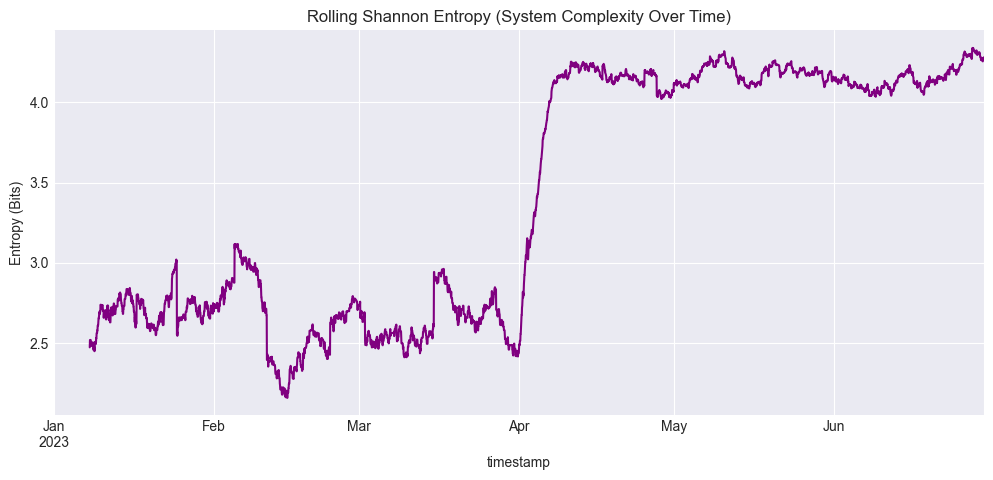

In [5]:
def calculate_entropy(series, bins=30):
    # Create a histogram of the data
    counts, _ = np.histogram(series, bins=bins, density=True)
    # Convert to probabilities
    probs = counts / np.sum(counts)
    # Remove zeros for log calculation
    probs = probs[probs > 0]
    # Calculate Shannon Entropy
    return -np.sum(probs * np.log2(probs))

entropy_val = calculate_entropy(df[target_col])
print(f"Shannon Entropy of {target_col}: {entropy_val:.4f} bits")

# Calculate entropy over a rolling window to see complexity changes over time
df['rolling_entropy'] = df[target_col].rolling(window=168).apply(calculate_entropy) # Weekly rolling

plt.figure(figsize=(12, 5))
df['rolling_entropy'].plot(color='purple')
plt.title('Rolling Shannon Entropy (System Complexity Over Time)')
plt.ylabel('Entropy (Bits)')
plt.show()

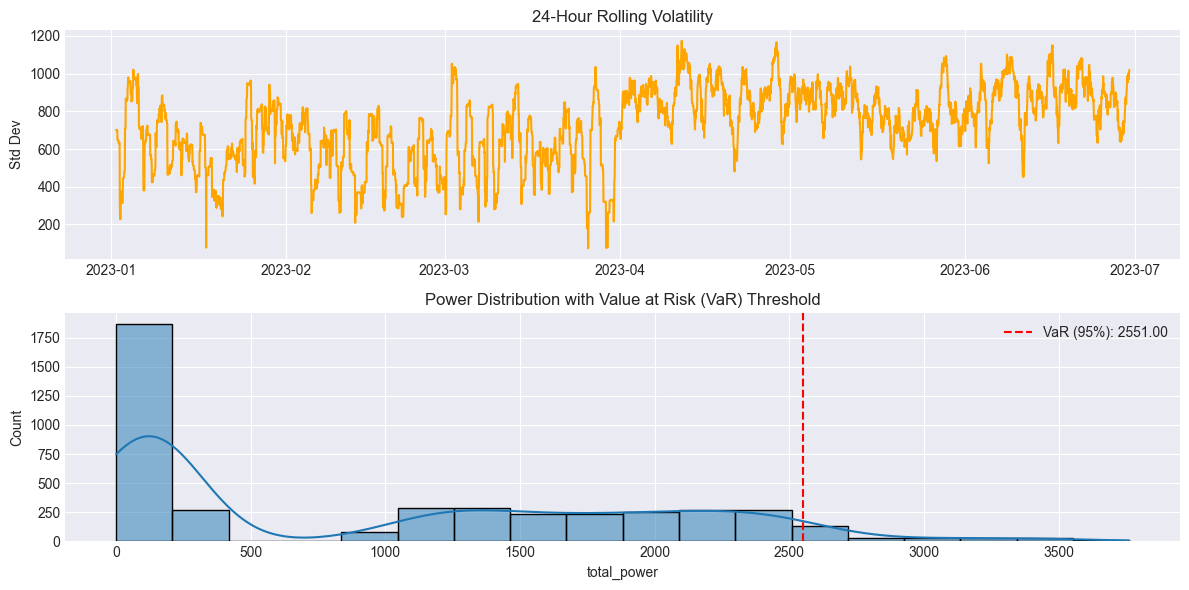

In [6]:
# Rolling Volatility
df['volatility'] = df[target_col].rolling(window=24).std()

# Value at Risk (95% Confidence)
var_95 = np.percentile(df[target_col], 95)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(df['volatility'], color='orange')
plt.title('24-Hour Rolling Volatility')
plt.ylabel('Std Dev')

plt.subplot(2, 1, 2)
sns.histplot(df[target_col], kde=True)
plt.axvline(var_95, color='red', linestyle='--', label=f'VaR (95%): {var_95:.2f}')
plt.title('Power Distribution with Value at Risk (VaR) Threshold')
plt.legend()

plt.tight_layout()
plt.show()

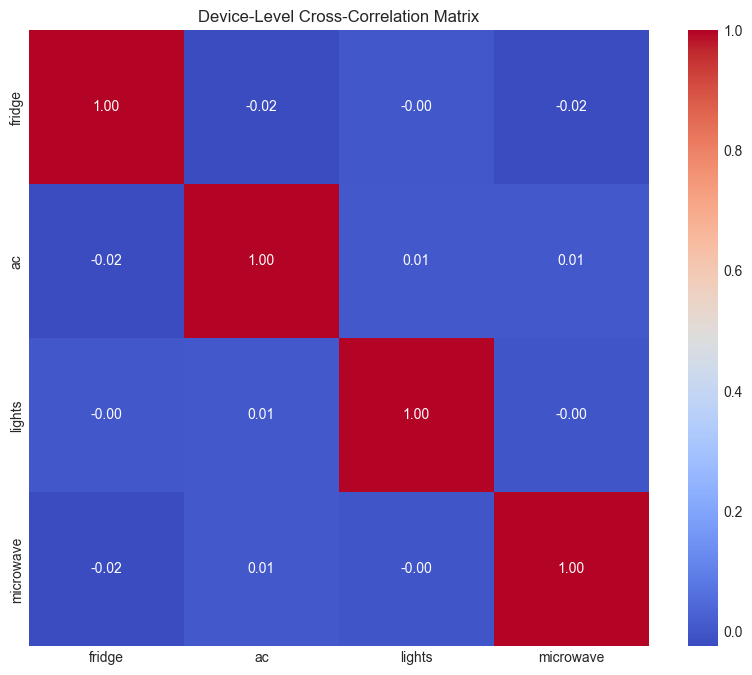

In [7]:
device_cols = ['fridge', 'ac', 'lights', 'microwave']
# Ensure these columns exist in df
existing_device_cols = [c for c in device_cols if c in df.columns]
if existing_device_cols:
    corr_matrix = df[existing_device_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Device-Level Cross-Correlation Matrix')
    plt.show()
else:
    print("Device columns not found for correlation analysis.")

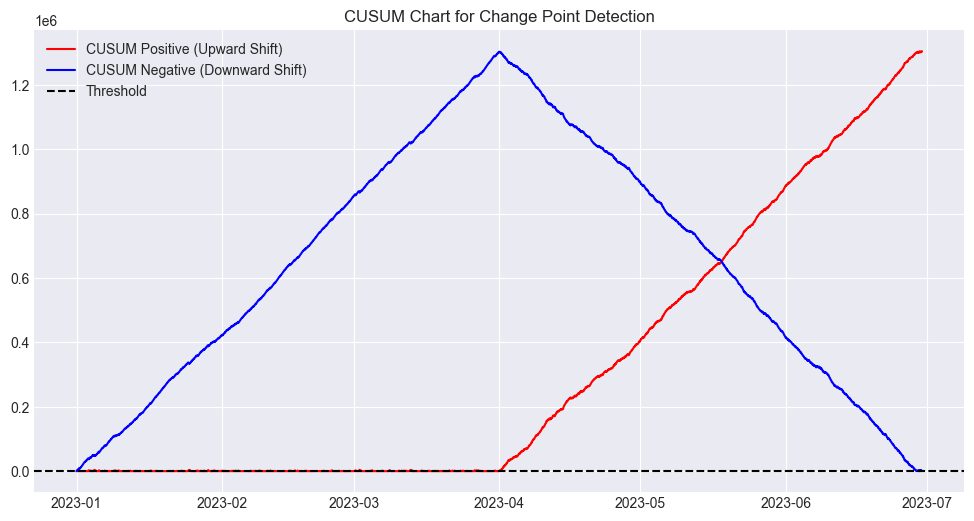

In [8]:
def detect_cusum(x, threshold=5, drift=0.5):
    S_pos = np.zeros(len(x))
    S_neg = np.zeros(len(x))
    mu = np.mean(x)
    
    for i in range(1, len(x)):
        S_pos[i] = max(0, S_pos[i-1] + (x[i] - mu) - drift)
        S_neg[i] = max(0, S_neg[i-1] - (x[i] - mu) - drift)
    
    return S_pos, S_neg

S_pos, S_neg = detect_cusum(df[target_col].values)

plt.figure(figsize=(12, 6))
plt.plot(df.index, S_pos, label='CUSUM Positive (Upward Shift)', color='red')
plt.plot(df.index, S_neg, label='CUSUM Negative (Downward Shift)', color='blue')
plt.axhline(50, color='black', linestyle='--', label='Threshold')
plt.title('CUSUM Chart for Change Point Detection')
plt.legend()
plt.show()

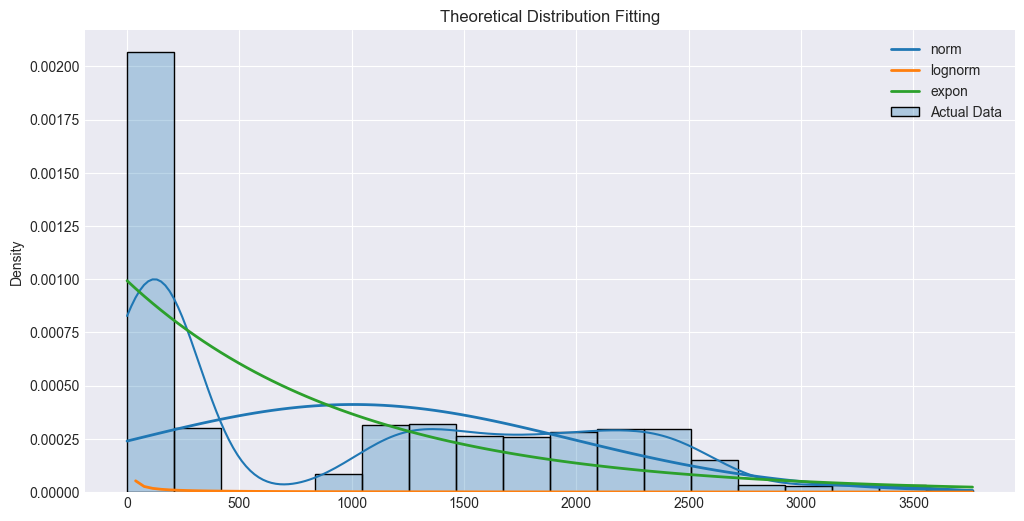

In [9]:
data = df[target_col].dropna().values
distributions = [stats.norm, stats.lognorm, stats.expon]

plt.figure(figsize=(12, 6))
sns.histplot(data, kde=True, stat="density", alpha=0.3, label='Actual Data')

x = np.linspace(min(data), max(data), 100)

for dist in distributions:
    params = dist.fit(data)
    pdf = dist.pdf(x, *params)
    plt.plot(x, pdf, label=dist.name, linewidth=2)

plt.title('Theoretical Distribution Fitting')
plt.legend()
plt.show()

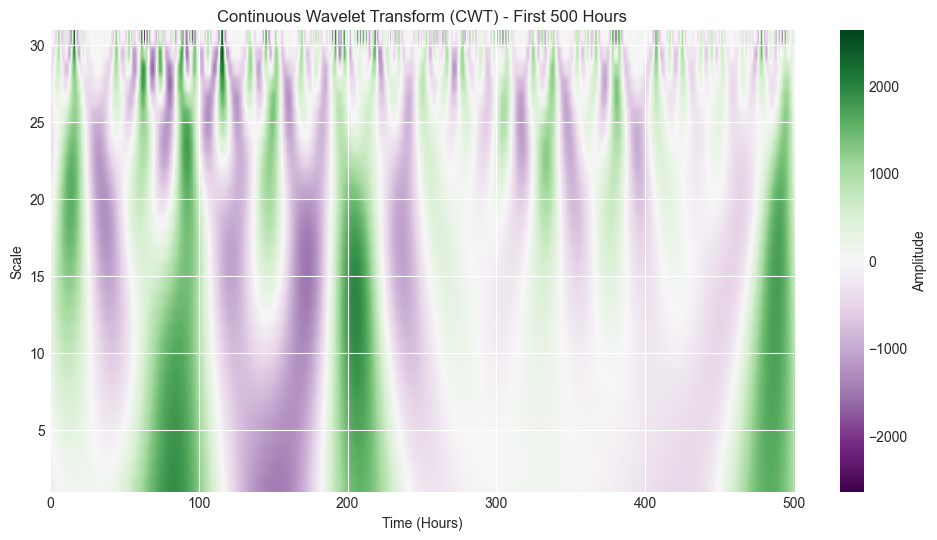

In [10]:
from scipy import signal

# Using a simple Ricker wavelet for Continuous Wavelet Transform (CWT)
widths = np.arange(1, 31)
cwtmatr = signal.cwt(df[target_col].values[:500], signal.ricker, widths)

plt.figure(figsize=(12, 6))
plt.imshow(cwtmatr, extent=[0, 500, 1, 31], cmap='PRGn', aspect='auto', vmax=abs(cwtmatr).max(), vmin=-abs(cwtmatr).max())
plt.title('Continuous Wavelet Transform (CWT) - First 500 Hours')
plt.ylabel('Scale')
plt.xlabel('Time (Hours)')
plt.colorbar(label='Amplitude')
plt.show()

<Figure size 1200x1200 with 0 Axes>

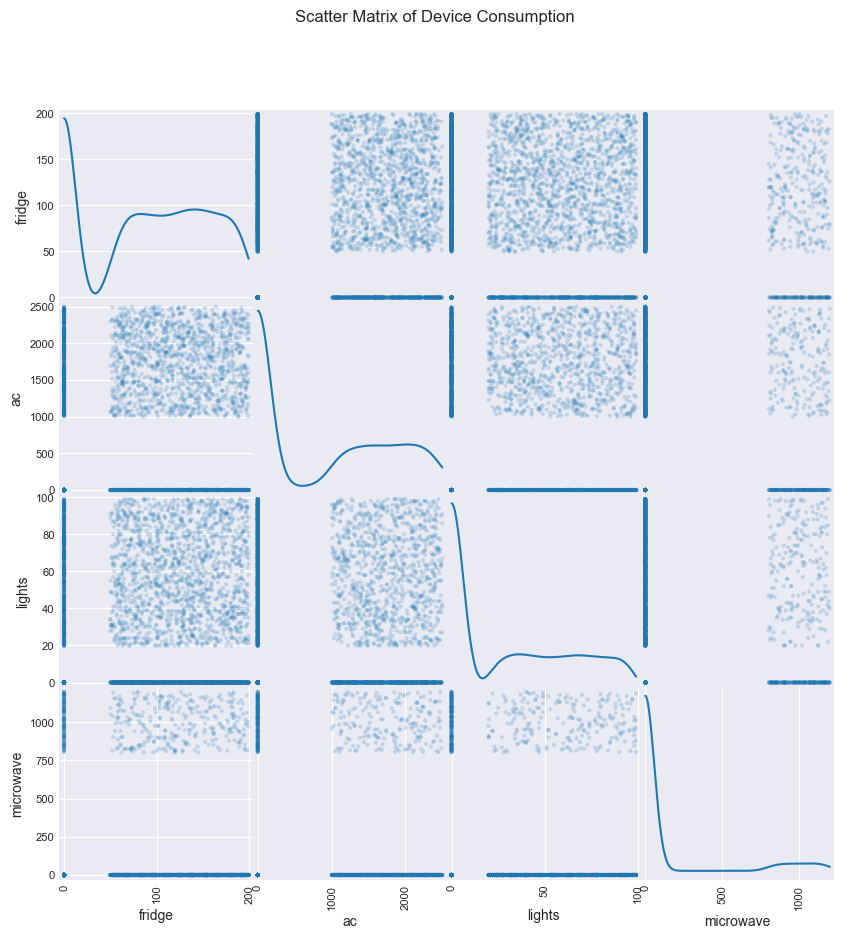

In [11]:
try:
    from pandas.plotting import scatter_matrix
    plt.figure(figsize=(12, 12))
    scatter_matrix(df[existing_device_cols], alpha=0.2, figsize=(10, 10), diagonal='kde')
    plt.suptitle('Scatter Matrix of Device Consumption')
    plt.show()
except Exception as e:
    print(f"Could not plot scatter matrix: {e}")